# Retrieval Evaluation

Testing FAISS retrieval quality with 15 queries the system hasn't seen before.
Metrics: Hit Rate, Precision@K, MRR


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import faiss
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from collections import Counter
import time

model = SentenceTransformer('all-MiniLM-L6-v2')

with open('data/sample_traces.json', 'r') as f:
    traces = json.load(f)

index = faiss.read_index('data/error_index.faiss')

with open('data/error_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"{len(traces)} traces, {index.ntotal} vectors, {index.d} dims")


50 traces, 50 vectors, 384 dims


In [2]:
Counter(t['framework'] for t in traces).most_common()

[('java-core', 17),
 ('spring-boot', 16),
 ('hibernate', 5),
 ('jackson', 3),
 ('jdbc', 3),
 ('spring-data', 3),
 ('security', 2),
 ('spring-security', 1)]

## Test Queries

15 queries across 3 difficulty levels. None of these exact strings are in the index

- easy: close to what's in the index (full exception names)
- medium: rephrased, partial information
- hard: shorter, closer to how you would actually search it


In [3]:
test_queries = [
    # easy
    {"query": "NoSuchBeanDefinitionException: No qualifying bean of type UserService",
     "expected": "NoSuchBeanDefinitionException", "framework": "spring-boot", "difficulty": "easy"},
    {"query": "LazyInitializationException: failed to lazily initialize a collection, could not initialize proxy - no Session",
     "expected": "LazyInitializationException", "framework": "hibernate", "difficulty": "easy"},
    {"query": "java.lang.OutOfMemoryError: Java heap space",
     "expected": "OutOfMemoryError", "framework": "java-core", "difficulty": "easy"},
    {"query": "JsonMappingException: No serializer found for class",
     "expected": "JsonMappingException", "framework": "jackson", "difficulty": "easy"},
    {"query": "BeanCurrentlyInCreationException: Is there an unresolvable circular reference?",
     "expected": "BeanCurrentlyInCreationException", "framework": "spring-boot", "difficulty": "easy"},

    # medium
    {"query": "Spring bean not found during autowiring",
     "expected": "NoSuchBeanDefinitionException", "framework": "spring-boot", "difficulty": "medium"},
    {"query": "Hibernate collection failed to load outside transaction",
     "expected": "LazyInitializationException", "framework": "hibernate", "difficulty": "medium"},
    {"query": "object references unsaved transient instance before flushing",
     "expected": "TransientPropertyValueException", "framework": "hibernate", "difficulty": "medium"},
    {"query": "Cannot deserialize String value to Integer in Jackson",
     "expected": "InvalidFormatException", "framework": "jackson", "difficulty": "medium"},
    {"query": "Spring Boot application port already in use on startup",
     "expected": "PortInUseException", "framework": "spring-boot", "difficulty": "medium"},

    # hard
    {"query": "NPE when calling method on null object",
     "expected": "NullPointerException", "framework": "java-core", "difficulty": "hard"},
    {"query": "spring circular dependency between two services",
     "expected": "BeanCurrentlyInCreationException", "framework": "spring-boot", "difficulty": "hard"},
    {"query": "hibernate session closed when accessing lazy loaded list",
     "expected": "LazyInitializationException", "framework": "hibernate", "difficulty": "hard"},
    {"query": "array index out of range exception in Java loop",
     "expected": "ArrayIndexOutOfBoundsException", "framework": "java-core", "difficulty": "hard"},
    {"query": "stack overflow from infinite recursion",
     "expected": "StackOverflowError", "framework": "java-core", "difficulty": "hard"},
]

len(test_queries)


15

## Evaluation

A result counts as relevant if the expected exception name appears in the indexed text


In [4]:
def search(query, k=5):
    emb = model.encode([query])
    emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    scores, indices = index.search(emb.astype('float32'), k)
    return [{"score": float(s), "metadata": metadata[i]}
            for s, i in zip(scores[0], indices[0]) if 0 <= i < len(metadata)]


def is_relevant(result, expected):
    """Match by exception name in the indexed text/source."""
    text = result["metadata"].get("text", "") + result["metadata"].get("source", "")
    return expected.lower() in text.lower()


results = []
for tq in test_queries:
    hits = search(tq["query"], k=5)
    rel = [is_relevant(r, tq["expected"]) for r in hits]
    results.append({**tq, "hits": hits, "relevance": rel,
                    "scores": [r["score"] for r in hits]})


In [5]:
def metrics_at_k(results, k):
    n = len(results)
    hit_rate = sum(any(r["relevance"][:k]) for r in results) / n
    precision = sum(sum(r["relevance"][:k]) / k for r in results) / n
    mrr = 0
    for r in results:
        for i, rel in enumerate(r["relevance"]):
            if rel:
                mrr += 1 / (i + 1)
                break
    return hit_rate, precision, mrr / n

for k in [1, 3, 5]:
    hr, pr, mrr = metrics_at_k(results, k)
    print(f"@{k}  hit_rate={hr:.0%}  precision={pr:.0%}  mrr={mrr:.2f}")


@1  hit_rate=87%  precision=87%  mrr=0.87
@3  hit_rate=87%  precision=31%  mrr=0.87
@5  hit_rate=87%  precision=19%  mrr=0.87


Breakdown by difficulty, expecting easy > medium > hard

In [6]:
for diff in ["easy", "medium", "hard"]:
    subset = [r for r in results if r["difficulty"] == diff]
    hr, pr, mrr = metrics_at_k(subset, 3)
    print(f"{diff:<8} hit_rate={hr:.0%}  precision={pr:.0%}  mrr={mrr:.2f}  (n={len(subset)})")


easy     hit_rate=80%  precision=33%  mrr=0.80  (n=5)
medium   hit_rate=100%  precision=33%  mrr=1.00  (n=5)
hard     hit_rate=80%  precision=27%  mrr=0.80  (n=5)


In [7]:
for r in results:
    q = r["query"][:60].ljust(60)
    hit = "HIT" if any(r["relevance"][:3]) else "MISS"
    print(f"{hit:<5} {r['difficulty']:<7} {r['scores'][0]:.3f}  {q}")


HIT   easy    0.659  NoSuchBeanDefinitionException: No qualifying bean of type Us
HIT   easy    0.804  LazyInitializationException: failed to lazily initialize a c
HIT   easy    0.833  java.lang.OutOfMemoryError: Java heap space                 
HIT   easy    0.659  JsonMappingException: No serializer found for class         
MISS  easy    0.739  BeanCurrentlyInCreationException: Is there an unresolvable c
HIT   medium  0.673  Spring bean not found during autowiring                     
HIT   medium  0.569  Hibernate collection failed to load outside transaction     
HIT   medium  0.675  object references unsaved transient instance before flushing
HIT   medium  0.746  Cannot deserialize String value to Integer in Jackson       
HIT   medium  0.736  Spring Boot application port already in use on startup      
HIT   hard    0.340  NPE when calling method on null object                      
MISS  hard    0.513  spring circular dependency between two services             
HIT   hard    0.

## Score Distribution

Checking how well the similarity score separates relevant from irrelevant results. Higher separation = easier to set a good threshold


In [8]:
rel_scores = [s for r in results for s, rv in zip(r["scores"], r["relevance"]) if rv]
irrel_scores = [s for r in results for s, rv in zip(r["scores"], r["relevance"]) if not rv]

print(f"relevant:   mean={np.mean(rel_scores):.3f}  median={np.median(rel_scores):.3f}  n={len(rel_scores)}")
print(f"irrelevant: mean={np.mean(irrel_scores):.3f}  median={np.median(irrel_scores):.3f}  n={len(irrel_scores)}")
print(f"separation: {np.mean(rel_scores) - np.mean(irrel_scores):.3f}")


relevant:   mean=0.646  median=0.666  n=14
irrelevant: mean=0.423  median=0.432  n=61
separation: 0.223


Left: score distribution for relevant vs irrelevant results (less overlap = better). Middle: hit rate broken down by query difficulty. Right: t-SNE projection of all 50 indexed vectors, shows whether error types form distinct clusters in embedding space

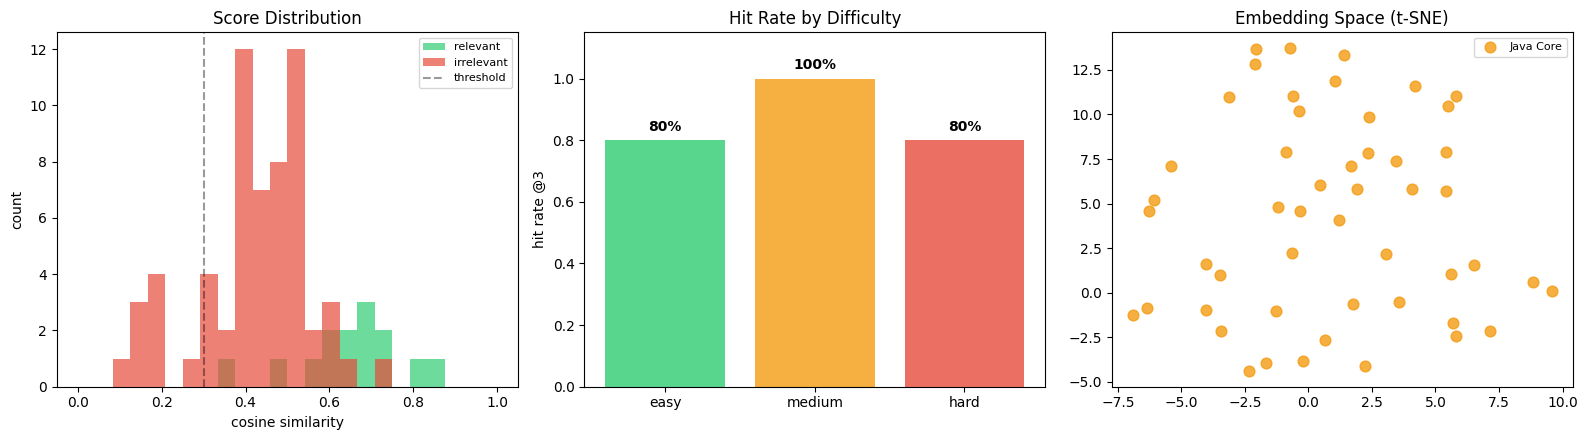

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# score histogram
bins = np.linspace(0, 1, 25)
axes[0].hist(rel_scores, bins=bins, alpha=0.7, label='relevant', color='#2ecc71')
axes[0].hist(irrel_scores, bins=bins, alpha=0.7, label='irrelevant', color='#e74c3c')
axes[0].axvline(x=0.3, color='black', linestyle='--', alpha=0.4, label='threshold')
axes[0].set_xlabel('cosine similarity')
axes[0].set_ylabel('count')
axes[0].legend(fontsize=8)
axes[0].set_title('Score Distribution')

# hit rate by difficulty
diffs = ["easy", "medium", "hard"]
hrs = [sum(any(r["relevance"][:3]) for r in results if r["difficulty"]==d)
       / sum(1 for r in results if r["difficulty"]==d) for d in diffs]
bars = axes[1].bar(diffs, hrs, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('hit rate @3')
axes[1].set_title('Hit Rate by Difficulty')
for b, h in zip(bars, hrs):
    axes[1].text(b.get_x() + b.get_width()/2, h + 0.03, f'{h:.0%}',
                ha='center', fontweight='bold', fontsize=10)

# t-SNE embedding space
all_embs = np.array([index.reconstruct(i) for i in range(index.ntotal)])
labels = []
for m in metadata:
    src = m.get("source", "").lower()
    if "spring" in src: labels.append("Spring")
    elif "hibernate" in src or "jpa" in src: labels.append("Hibernate")
    elif "jackson" in src: labels.append("Jackson")
    else: labels.append("Java Core")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, index.ntotal-1))
proj = tsne.fit_transform(all_embs)

colors = {"Spring": "#2ecc71", "Hibernate": "#3498db", "Jackson": "#e74c3c", "Java Core": "#f39c12"}
for label, color in colors.items():
    mask = np.array([l == label for l in labels])
    if mask.any():
        axes[2].scatter(proj[mask, 0], proj[mask, 1], c=color, label=label, s=60, alpha=0.8)
axes[2].legend(fontsize=8)
axes[2].set_title('Embedding Space (t-SNE)')

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Failures

In [10]:
failures = [r for r in results if not any(r["relevance"][:3])]
print(f"{len(results) - len(failures)}/{len(results)} successful\n")

for f in failures:
    print(f"query:    {f['query']}")
    print(f"expected: {f['expected']}")
    print(f"got:      {f['hits'][0]['metadata'].get('text', '')[:80]}")
    print(f"score:    {f['scores'][0]:.3f}  ({f['difficulty']})\n")


13/15 successful

query:    BeanCurrentlyInCreationException: Is there an unresolvable circular reference?
expected: BeanCurrentlyInCreationException
got:      org.springframework.beans.factory.BeanCreationException: Error creating bean wit
score:    0.739  (easy)

query:    spring circular dependency between two services
expected: BeanCurrentlyInCreationException
got:      org.springframework.beans.factory.BeanCreationException: Error creating bean wit
score:    0.513  (hard)



## Latency

In [11]:
embed_t, search_t = [], []

for _ in range(3):
    for tq in test_queries:
        t0 = time.perf_counter()
        emb = model.encode([tq["query"]])
        emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        t1 = time.perf_counter()
        index.search(emb.astype('float32'), 5)
        t2 = time.perf_counter()
        embed_t.append((t1-t0)*1000)
        search_t.append((t2-t1)*1000)

print(f"embedding:  {np.mean(embed_t):.1f}ms avg, {np.percentile(embed_t, 95):.1f}ms p95")
print(f"faiss:      {np.mean(search_t):.2f}ms avg")
print(f"total:      {np.mean(embed_t) + np.mean(search_t):.1f}ms avg  ({len(embed_t)} runs)")


embedding:  16.7ms avg, 46.0ms p95
faiss:      0.03ms avg
total:      16.7ms avg  (45 runs)
